In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image
from dinosaw.models.vit_wrapper import AlibiVitWrapper, MODEL_LIST
from dinosaw.helpers import get_features, add_custom_font
from dinosaw.utils import do_2D_pca
DEVICE="cuda:0"

/home/pawlo/miniforge3/envs/minimal_dinosaw/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
path_constant = "../../trained_models/alibi_const/best_model.pth"
path_learned = "../../trained_models/alibi_learned/best_model.pth"
path_learned = "/home/pawlo/Arbeit/positional_bias/dino-saw/dinosaw/experiments/20260206_2352_alibi_wrap_leaned_slope_real_100_224_homog_bs16/best_model.pth"
HALF=True

In [35]:
alibi_learned = AlibiVitWrapper(
    model_identifier=MODEL_LIST[1],
    slope_type="learned",
    add_flash_attn=False,
    device=DEVICE
)
alibi_learned.load_state_dict(torch.load(path_learned, weights_only=True, map_location=DEVICE))


<All keys matched successfully>

In [26]:
alibi_const = AlibiVitWrapper(
    model_identifier=MODEL_LIST[1],
    slope_type="constant",
    add_flash_attn=False,
    device=DEVICE
)
alibi_const.load_state_dict(torch.load(path_constant, weights_only=True, map_location=DEVICE))

<All keys matched successfully>

In [36]:
models = [alibi_const, alibi_learned]
for model in models:
    model.eval()
    print(model.model.blocks[0].attn.m)
    if HALF:
        model.half()

tensor([[[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]]], device='cuda:0', dtype=torch.float16)
Parameter containing:
tensor([[[ 0.2173]],

        [[ 0.5493]],

        [[ 0.8903]],

        [[ 0.5180]],

        [[ 0.7163]],

        [[-0.0499]]], device='cuda:0', requires_grad=True)


In [ ]:
SF=1
img_fname="wmg_si_c.png"
# img_fname="bimodal_zoom.png"
# img_fname="black_square.png"
# img_fname="NMC_2D_crop.png"

img_path = f"../images/{img_fname}"
img = Image.open(img_path).convert('RGB')
img = img.resize((int(SF * img.width), int(SF * img.height)), Image.LANCZOS)


In [38]:
feats_reduced = {channel_group: {} for channel_group in range(3)}

for i, model in enumerate(models):
    feats = get_features(model, img, to_half=HALF, device=DEVICE)
    for channel_group in range(3):
        feats_reduced[channel_group][i] = do_2D_pca(feats, (channel_group+1)*3, pre_norm="std", post_norm='minmax')[:, :, channel_group*3:channel_group*3+3]

In [39]:
# for channel_group in range(3):
#     feats_reduced[channel_group][i] = do_2D_pca(feats, (channel_group+1)*3, pre_norm="std", post_norm='minmax')[:, :, channel_group*3:channel_group*3+3]

In [40]:
import numpy as np

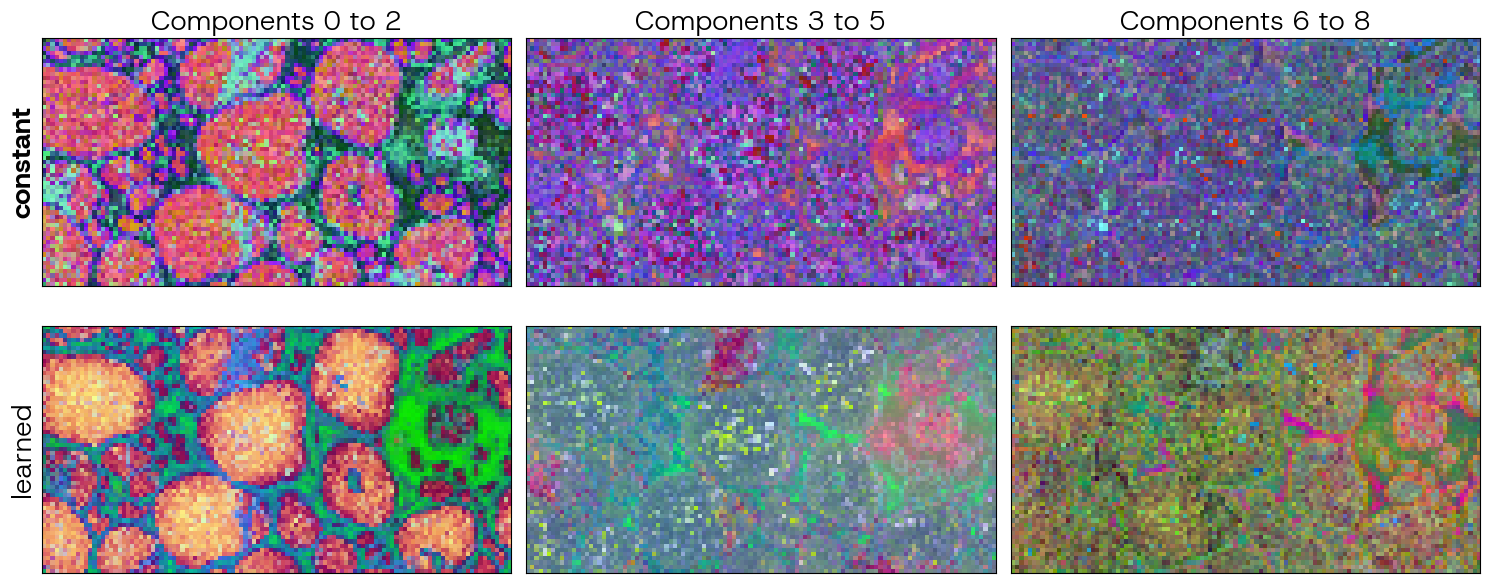

In [41]:
FS=20
H,W = 6.4,15
NROWS, NCOLS = 2,3
fig = plt.figure(figsize=(W,H))
gs = GridSpec(NROWS, NCOLS, figure=fig)

add_custom_font("resources/fonts/")

for j, _ in enumerate(models):
    for i, channel_group in enumerate(list(range(3))):
        ax = fig.add_subplot(gs[j, i])
        ax.imshow(feats_reduced[channel_group][j])
        ax.set_yticks([])
        ax.set_xticks([])
        if j==0:
            ax.set_title(f"Components {channel_group*3} to {channel_group*3+2}", fontsize=FS)
        if i==0:
            if j==0:
                ax.set_ylabel("constant", fontsize=FS, weight="bold")
            else:
                ax.set_ylabel("learned", fontsize=FS)

plt.tight_layout()